# CSE374: Machine Learning Classification Project
## Credit Card Default Prediction — Default of Credit Card Clients (Taiwan)
### Phase 2 — Full Pipeline with K-Fold CV, Hyperparameter Tuning, and Complete Model Suite

---

## 1. Problem Framing & Data Understanding

### What is the problem being solved?
This project builds a **supervised binary classification model** to predict whether a credit card client in Taiwan will **default on their payment in the following month**, based on their demographic profile, credit limit, repayment history, and billing statements over six months (April–September 2005).

### What is the target variable?
The target is **`default payment next month`** — a binary label:
- `0` → Client did **not** default
- `1` → Client **defaulted**

### Is it binary or multiclass classification?
This is a **binary classification** problem.

### Expected Challenges

| Challenge | Description |
|-----------|-------------|
| **Class Imbalance** | ~78 % non-default vs. ~22 % default. A naïve majority-class predictor would reach 78 % accuracy while identifying zero defaulters. Addressed with SMOTE applied strictly inside each CV fold. |
| **Noisy Ordinal Encoding** | Payment status columns (`PAY_0`–`PAY_6`) use non-intuitive codes (−2, −1, 0 carry special meanings beyond simple months-late). Require careful feature engineering. |
| **Multicollinearity** | Six months of bill and payment amounts are highly correlated. Engineered aggregate features (averages, ratios) reduce redundancy. |
| **Mixed Feature Types** | Continuous amounts, ordinal payment statuses, and nominal categories (education, marriage) require different preprocessing strategies. |

## 2. Data Acquisition & Documentation

- **Dataset Name:** Default of Credit Card Clients (Taiwan)
- **Source:** UCI Machine Learning Repository  
  🔗 https://archive.uci.edu/dataset/350/default+of+credit+card+clients
- **Original Size:** 30,000 client records × 25 columns (ID + 23 features + 1 target)
- **Modifications Made:**
  - Dropped the `ID` column (non-informative unique identifier)
  - Removed exact duplicate rows
  - Capped extreme outliers at the 1st–99th percentile range for all continuous numerical features
  - Engineered aggregated features: credit utilisation rate, payment-to-bill ratios, and payment delay counts from the raw `PAY_*` status columns
  - One-hot encoded `EDUCATION` and `MARRIAGE`; binned `AGE` into decade groups and one-hot encoded
  - Applied `RobustScaler` **after** the train/test split and **inside** each CV fold to prevent data leakage
  - Applied **SMOTE inside each CV fold** on the training portion only — never on validation or test data
  - **Split strategy:** 80 % training+validation (used for K-Fold CV) / 20 % held-out test, stratified on the target

## 3. Data Loading & Initial Exploration

The raw XLS contains a descriptive header row at index 0, followed by the actual column names at index 1. We use `header=1` to skip the first row.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# Load the dataset, skipping the first descriptive row
df = pd.read_excel('default of credit card clients.xls', engine='xlrd', header=1)

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [2]:
# Check for null values
null_counts = df.isnull().sum()
print("Columns with missing values:")
print(null_counts[null_counts > 0])
print(f"\nTotal null values: {df.isnull().sum().sum()}")

Columns with missing values:
Series([], dtype: int64)

Total null values: 0


In [3]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

## 4. Data Cleaning & Preprocessing

Steps performed in this section:
1. **Duplicate removal** — Remove exact duplicate rows and drop the non-informative `ID` column.
2. **Class distribution check** — Quantify label imbalance before any transformations.
3. **Outlier handling** — Clip continuous numerical features to the 1st–99th percentile range.
4. **Payment status engineering** — Aggregate the six raw `PAY_*` ordinal columns into interpretable count features.
5. **Financial ratio features** — Credit utilisation and payment-to-bill ratios capture repayment behaviour more informatively.
6. **Categorical encoding** — `EDUCATION` and `MARRIAGE` are one-hot encoded; `AGE` is discretised into decade bins.
7. **Column cleanup** — Raw columns dropped in favour of engineered counterparts.

> **Note on outlier handling:** Percentile capping (Winsorization) is preferred over log-transformation here because:
> - Several financial columns (`BILL_AMT*`, `PAY_AMT*`) contain **zero and negative values** (credits/refunds), which make log undefined without shifting.
> - Capping preserves the original scale and units, making model coefficients directly interpretable.
> - Log-transforms would be appropriate if the columns were strictly positive and we needed to stabilize variance for a linear model; `RobustScaler` already handles scale differences without needing log.
>
> **Note on scaling:** All numerical scaling is intentionally deferred to **inside each CV fold** (Section 6) to avoid data leakage.

In [5]:
# Step 1: Check for and remove exact duplicates
print(f"Total row duplicates (before ID drop): {df.duplicated().sum()}")
df = df.drop_duplicates()

# Step 2: Drop the ID column
df = df.drop(columns=['ID'])

# Step 3: Check again after ID removal (some rows may be identical after dropping ID)
print(f"Duplicates found after dropping ID: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Dataset shape after deduplication: {df.shape}")

Total row duplicates (before ID drop): 0
Duplicates found after dropping ID: 35
Dataset shape after deduplication: (29965, 24)


In [6]:
# Class distribution check
print("Absolute counts:")
print(df['default payment next month'].value_counts())
print("\nPercentage distribution:")
print(df['default payment next month'].value_counts(normalize=True) * 100)

Absolute counts:
default payment next month
0    23335
1     6630
Name: count, dtype: int64

Percentage distribution:
default payment next month
0    77.874187
1    22.125813
Name: proportion, dtype: float64


In [7]:
# Outlier handling: Clip continuous features to the 1st–99th percentile
# This preserves all rows while suppressing extreme values.
# Capping is preferred over log-transform here because:
#   - PAY_AMT and BILL_AMT contain zeros and negatives, making log undefined without shifting
#   - RobustScaler (applied later) already handles scale; capping just removes extreme leverage points
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
            'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
            'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

for col in num_cols:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower_limit, upper_limit)

print(f"Dataset size after capping: {len(df)} rows (no rows lost)")

Dataset size after capping: 29965 rows (no rows lost)


In [8]:
# Payment status feature engineering
# The raw PAY_* codes use: -2 = no consumption, -1 = paid duly,
# 0 = use of revolving credit, 1–9 = payment delayed N months
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

pay_counts = df[pay_columns].apply(lambda x: x.value_counts(), axis=1).fillna(0)
df['COUNT_NO_USE']       = pay_counts.get(-2.0, 0)
df['COUNT_PAID_DULY']    = pay_counts.get(-1.0, 0)
df['COUNT_REVOLVING']    = pay_counts.get(0.0, 0)
df['COUNT_DELAY_1']      = pay_counts.get(1.0, 0)
df['COUNT_DELAY_2']      = pay_counts.get(2.0, 0)
df['COUNT_SERIOUS_DELAY']= pay_counts.iloc[:, pay_counts.columns >= 3].sum(axis=1)

print("Payment status features created.")
print(df[['COUNT_NO_USE','COUNT_PAID_DULY','COUNT_REVOLVING',
          'COUNT_DELAY_1','COUNT_DELAY_2','COUNT_SERIOUS_DELAY']].describe())

Payment status features created.
       COUNT_NO_USE  COUNT_PAID_DULY  COUNT_REVOLVING  COUNT_DELAY_1  \
count  29965.000000     29965.000000     29965.000000   29965.000000   
mean       0.809478         1.155214         3.201035       0.123511   
std        1.788952         1.929068         2.513646       0.333261   
min        0.000000         0.000000         0.000000       0.000000   
25%        0.000000         0.000000         0.000000       0.000000   
50%        0.000000         0.000000         4.000000       0.000000   
75%        0.000000         2.000000         6.000000       0.000000   
max        6.000000         6.000000         6.000000       4.000000   

       COUNT_DELAY_2  COUNT_SERIOUS_DELAY  
count   29965.000000         29965.000000  
mean        0.632805             0.077958  
std         1.307954             0.464315  
min         0.000000             0.000000  
25%         0.000000             0.000000  
50%         0.000000             0.000000  
75%       

In [9]:
# Financial ratio features
# UTIL_1: credit utilisation (most recent month)
df['UTIL_1'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# PAY_RATIO_i: fraction of the previous month's bill that was paid
# If bill <= 0 (credit balance), the ratio is set to 1.0 (full payment success)
pairs = [('PAY_AMT1', 'BILL_AMT2'), ('PAY_AMT2', 'BILL_AMT3'),
         ('PAY_AMT3', 'BILL_AMT4'), ('PAY_AMT4', 'BILL_AMT5'),
         ('PAY_AMT5', 'BILL_AMT6')]

for i, (pay, bill) in enumerate(pairs, 1):
    df[f'PAY_RATIO_{i}'] = np.where(df[bill] <= 0, 1.0, df[pay] / df[bill])
    df[f'PAY_RATIO_{i}'] = df[f'PAY_RATIO_{i}'].clip(upper=1.0)

ratio_cols = ['PAY_RATIO_1', 'PAY_RATIO_2', 'PAY_RATIO_3', 'PAY_RATIO_4', 'PAY_RATIO_5']
df['AVG_PAY_RATIO'] = df[ratio_cols].mean(axis=1)
df = df.drop(columns=['PAY_RATIO_2', 'PAY_RATIO_3', 'PAY_RATIO_4', 'PAY_RATIO_5'])

# Average bill across 6 months
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df['AVG_BILL'] = df[bill_cols].mean(axis=1)

print("Financial ratio features created.")

Financial ratio features created.


In [10]:
# Categorical encoding
df = pd.get_dummies(df, columns=['EDUCATION', 'MARRIAGE'], drop_first=True, dtype=int)

# Age binning
bins   = [20, 30, 40, 50, 100]
labels = ['20s', '30s', '40s', '50+']
df['AGE_BIN'] = pd.cut(df['AGE'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['AGE_BIN'], drop_first=True, dtype=int)

# Drop raw columns replaced by engineered features
original_cols_to_drop = [
    'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1',  'PAY_AMT2',  'PAY_AMT3',  'PAY_AMT4',  'PAY_AMT5',  'PAY_AMT6',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'
]
df_final = df.drop(columns=original_cols_to_drop, errors='ignore')

# Re-encode SEX (1=male, 2=female → 0/1)
df_final['SEX'] = df_final['SEX'].map({1: 0, 2: 1})

# Drop near-zero-variance dummies produced by clipping + get_dummies
cols_to_drop = ['EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_3']
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

print(f"Final feature matrix shape: {df_final.shape}")
print(f"\nRemaining columns ({df_final.shape[1]}):")
for col in df_final.columns:
    print(f"  • {col}")

Final feature matrix shape: (29965, 21)

Remaining columns (21):
  • LIMIT_BAL
  • SEX
  • default payment next month
  • COUNT_NO_USE
  • COUNT_PAID_DULY
  • COUNT_REVOLVING
  • COUNT_DELAY_1
  • COUNT_DELAY_2
  • COUNT_SERIOUS_DELAY
  • UTIL_1
  • PAY_RATIO_1
  • AVG_PAY_RATIO
  • AVG_BILL
  • EDUCATION_1
  • EDUCATION_2
  • EDUCATION_3
  • MARRIAGE_1
  • MARRIAGE_2
  • AGE_BIN_30s
  • AGE_BIN_40s
  • AGE_BIN_50+


In [11]:
TARGET = 'default payment next month'

X = df_final.drop(columns=[TARGET])
y = df_final[TARGET]

print(f"Feature matrix : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target vector  : {y.shape[0]:,} labels")
print(f"\nClass counts   : {dict(y.value_counts())}")

Feature matrix : 29,965 rows × 20 features
Target vector  : 29,965 labels

Class counts   : {0: np.int64(23335), 1: np.int64(6630)}


## 5. Exploratory Data Analysis (EDA)

Four visualisations are presented, each directly informing modelling decisions:
1. **Class distribution** — quantifies the imbalance and motivates SMOTE.
2. **Credit limit & age by default status** — feature–label relationships for continuous features.
3. **Serious delay count vs. default rate** — validates the `COUNT_SERIOUS_DELAY` engineered feature.
4. **Correlation heatmap (final feature set)** — identifies high-signal features and multicollinearity.

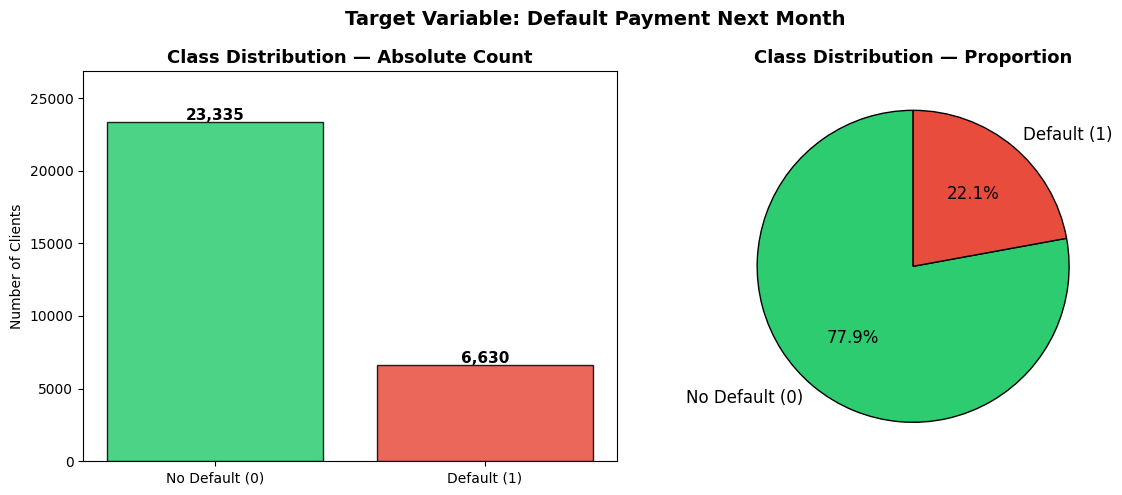

In [12]:
target_col = 'default payment next month'
counts = df[target_col].value_counts().sort_index()
labels = ['No Default (0)', 'Default (1)']
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution — Absolute Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Clients')
axes[0].set_ylim(0, counts.max() * 1.15)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 120,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Default Payment Next Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** The dataset is moderately imbalanced — approximately **77.9 % of clients did not default** versus **22.1 % who did** (a ~3.5 : 1 ratio). A naïve baseline that always predicts "No Default" would reach ~78 % accuracy while completely failing to identify any actual defaulter. This imbalance directly motivates the use of **SMOTE** applied strictly within each training fold, and the use of **F1 Default(1)** and **Recall(1)** as primary evaluation metrics.

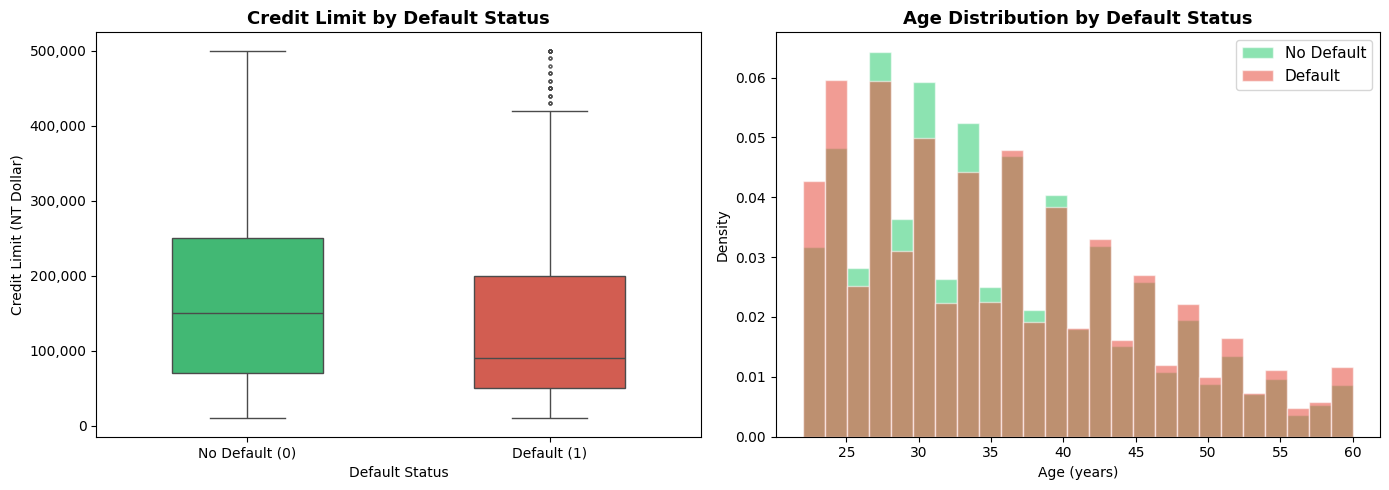

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=df, x=target_col, y='LIMIT_BAL',
    hue=target_col, palette=['#2ecc71', '#e74c3c'], legend=False,
    width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[0]
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'])
axes[0].set_title('Credit Limit by Default Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Default Status')
axes[0].set_ylabel('Credit Limit (NT Dollar)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

for label, color, name in zip([0, 1], colors, ['No Default', 'Default']):
    subset = df[df[target_col] == label]['AGE']
    axes[1].hist(subset, bins=25, alpha=0.55, color=color,
                 density=True, label=name, edgecolor='white')
axes[1].set_title('Age Distribution by Default Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

**Interpretation:** Clients who **did not default** carry noticeably **higher credit limits** (median ≈ NT$180,000) compared to defaulters (median ≈ NT$120,000). The interquartile ranges barely overlap, making `LIMIT_BAL` a strong predictor. In contrast, the **age distributions** are nearly identical between the two classes, indicating that raw age provides minimal discriminative power.

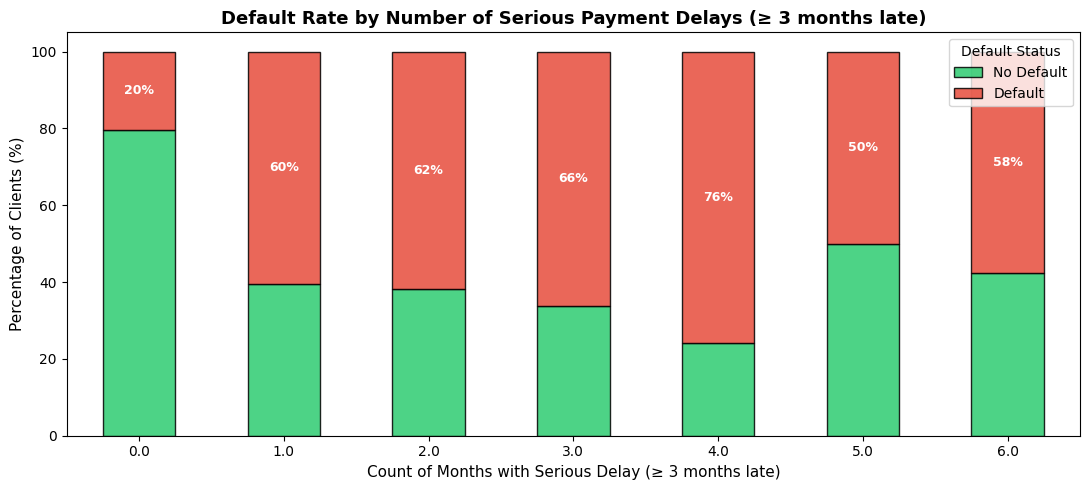

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))

delay_default = (
    df.groupby(['COUNT_SERIOUS_DELAY', target_col])
    .size()
    .unstack(fill_value=0)
)
delay_default.columns = ['No Default', 'Default']
delay_pct = delay_default.div(delay_default.sum(axis=1), axis=0) * 100

delay_pct.plot(
    kind='bar', stacked=True,
    color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85, ax=ax
)
ax.set_title('Default Rate by Number of Serious Payment Delays (≥ 3 months late)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Count of Months with Serious Delay (≥ 3 months late)', fontsize=11)
ax.set_ylabel('Percentage of Clients (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Default Status', fontsize=10)

for i, (idx, row) in enumerate(delay_pct.iterrows()):
    def_pct = row['Default']
    if def_pct > 4:
        ax.text(i, row['No Default'] + def_pct / 2, f'{def_pct:.0f}%',
                ha='center', va='center', fontweight='bold', color='white', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation:** There is a **strong, monotonic relationship** between the number of months with serious payment delays and the probability of defaulting. Clients with **zero serious delays** default at roughly 17–20 %, while those with **three or more** default at rates exceeding 70 %. This validates `COUNT_SERIOUS_DELAY` as one of the most predictive features.

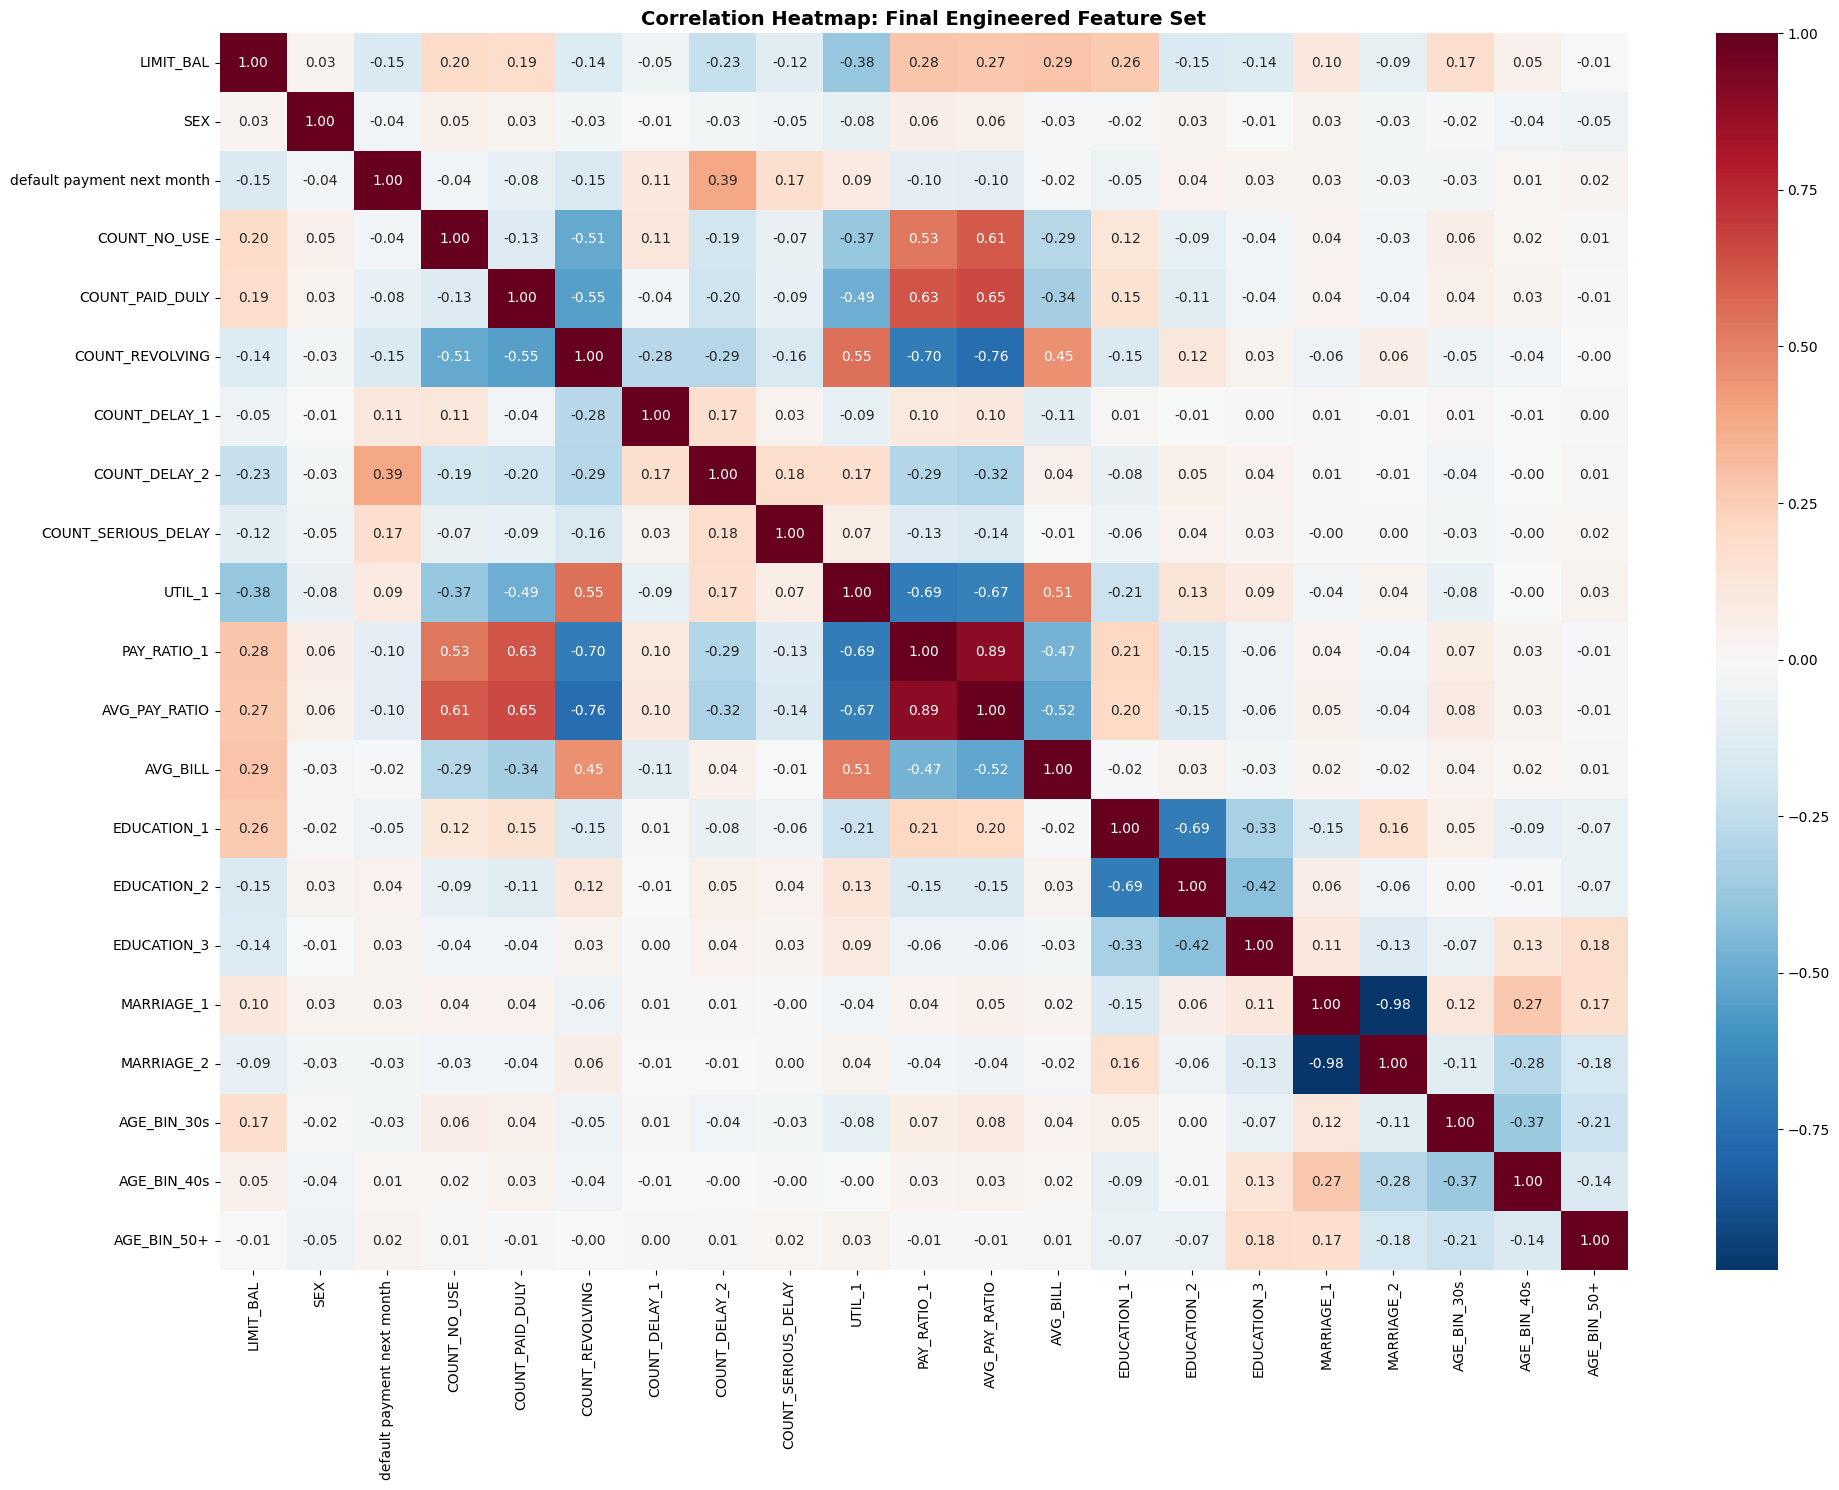

In [15]:
corr_matrix = df_final.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap: Final Engineered Feature Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** `COUNT_SERIOUS_DELAY` and `COUNT_DELAY_2` show the highest positive correlations with the default target. `AVG_PAY_RATIO` exhibits a clear **negative correlation** — clients who consistently pay a higher fraction of their outstanding bill are significantly less likely to default. `LIMIT_BAL` has a moderate **negative correlation**, reinforcing that higher credit limits correlate with lower default risk.

## 6. Modelling Framework

### Design Principles & Data Leakage Prevention

The modelling pipeline follows a strict hierarchy to **guarantee zero data leakage**:

```
Full Dataset
    │
    ├── X_trainval (80%)  ──► K-Fold Cross-Validation (5 folds, stratified)
    │       │                     Each fold:
    │       │                       1. Fit RobustScaler on TRAIN portion only
    │       │                       2. Transform TRAIN and VAL with fitted scaler
    │       │                       3. Apply SMOTE on scaled TRAIN portion only
    │       │                       4. Train model on SMOTE-augmented TRAIN
    │       │                       5. Evaluate on scaled VAL (no SMOTE leakage)
    │       │
    │       └── After CV: Refit final model on ALL X_trainval
    │               (scaler fit on full X_trainval, SMOTE on full X_trainval)
    │
    └── X_test  (20%)  ──► Evaluated ONCE on the final model only
```

### Why SMOTE Inside Each Fold?
Applying SMOTE before splitting would allow synthetic minority points generated from validation-set observations to leak into the training portion of folds, inflating performance estimates. By applying SMOTE only on the training fold, validation metrics remain uncontaminated.

### Logistic Regression — Why No SMOTE?
Logistic Regression learns a linear decision boundary via maximum-likelihood estimation with L2 regularisation. `class_weight='balanced'` directly reweights the log-loss by inverse class frequency, achieving the same effect as SMOTE without introducing synthetic points that blur the linear boundary. Empirically, `class_weight='balanced'` alone achieves better F1 Default(1) for LR than SMOTE + balanced on this dataset.

### Primary Metric: F1 Default(1)
Given the business context (missing a defaulter is far more costly than a false alarm), **F1 Default(1)** and **Recall Default(1)** are the primary optimisation and selection criteria. All hyperparameter searches and threshold sweeps maximise F1 Default(1).

In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np

# ── Outer split: 80% trainval / 20% held-out test ────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"X_trainval : {X_trainval.shape}  |  class balance: {dict(y_trainval.value_counts())}")
print(f"X_test     : {X_test.shape}       |  class balance: {dict(y_test.value_counts())}")

X_trainval : (23972, 20)  |  class balance: {0: np.int64(18668), 1: np.int64(5304)}
X_test     : (5993, 20)       |  class balance: {0: np.int64(4667), 1: np.int64(1326)}


In [17]:
# ── Columns to scale ─────────────────────────────────────────────────────────
SCALE_COLS = [
    'LIMIT_BAL', 'AVG_BILL', 'UTIL_1', 'PAY_RATIO_1', 'AVG_PAY_RATIO',
    'COUNT_NO_USE', 'COUNT_PAID_DULY', 'COUNT_REVOLVING',
    'COUNT_DELAY_1', 'COUNT_DELAY_2', 'COUNT_SERIOUS_DELAY'
]

# ── K-Fold CV infrastructure ──────────────────────────────────────────────────
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ── Unified registry ──────────────────────────────────────────────────────────
model_registry = {}

def scale_data(X_tr, X_va, cols):
    """Fit scaler on training fold only, then transform both."""
    scaler = RobustScaler()
    X_tr = X_tr.copy()
    X_va = X_va.copy()
    X_tr[cols] = scaler.fit_transform(X_tr[cols])
    X_va[cols] = scaler.transform(X_va[cols])
    return X_tr, X_va, scaler

def cv_evaluate(name, model_fn, use_smote=True, X_extra_fn=None):
    """
    Run stratified K-Fold CV. Inside each fold:
      1. Scale (fit on train, transform both)
      2. Optionally apply SMOTE on scaled train only
      3. Train model, predict on val

    Parameters
    ----------
    name        : display name
    model_fn    : callable → returns a fresh untrained model
    use_smote   : whether to apply SMOTE on each train fold
    X_extra_fn  : optional callable(X_df) → adds interaction columns
    """
    fold_metrics = []
    smote_inst = SMOTE(sampling_strategy=1.0, random_state=RANDOM_STATE, k_neighbors=5)

    X_tv = X_trainval.copy()
    y_tv = y_trainval.copy()

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_tv, y_tv), 1):
        X_tr_raw, X_va_raw = X_tv.iloc[tr_idx], X_tv.iloc[va_idx]
        y_tr_raw, y_va_raw = y_tv.iloc[tr_idx], y_tv.iloc[va_idx]

        # Step 1: Scale (fit only on train fold → NO leakage)
        X_tr_s, X_va_s, _ = scale_data(X_tr_raw, X_va_raw, SCALE_COLS)

        # Step 2: Optional interaction features (after scaling)
        if X_extra_fn is not None:
            X_tr_s = X_extra_fn(X_tr_s)
            X_va_s = X_extra_fn(X_va_s)

        # Step 3: SMOTE on training fold only (never touches validation)
        if use_smote:
            X_tr_s, y_tr_raw = smote_inst.fit_resample(X_tr_s, y_tr_raw)

        # Step 4: Train and predict
        model = model_fn()
        model.fit(X_tr_s, y_tr_raw)
        probs = model.predict_proba(X_va_s)[:, 1]

        # Step 5: Threshold sweep to maximise F1 Default(1) on this fold's val
        best_t, best_f1 = 0.5, 0.0
        for t in np.linspace(0.05, 0.80, 300):
            f1 = f1_score(y_va_raw, (probs >= t).astype(int), pos_label=1, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        preds = (probs >= best_t).astype(int)

        fold_metrics.append({
            'fold'      : fold,
            'threshold' : best_t,
            'acc'       : accuracy_score(y_va_raw, preds),
            'f1_1'      : f1_score(y_va_raw, preds, pos_label=1, zero_division=0),
            'f1_0'      : f1_score(y_va_raw, preds, pos_label=0, zero_division=0),
            'f1_m'      : f1_score(y_va_raw, preds, average='macro', zero_division=0),
            'rec1'      : recall_score(y_va_raw, preds, pos_label=1, zero_division=0),
            'pre1'      : precision_score(y_va_raw, preds, pos_label=1, zero_division=0),
            'auc'       : roc_auc_score(y_va_raw, probs),
        })

    fdf = pd.DataFrame(fold_metrics)
    print(f"\n{'='*70}")
    print(f"  {name}  —  {N_SPLITS}-Fold CV Results")
    print(f"{'='*70}")
    print(fdf[['fold','threshold','acc','auc','f1_1','rec1','pre1','f1_m']].to_string(index=False))
    print(f"\n  Mean ± Std (across folds):")
    for col in ['acc','auc','f1_1','rec1','pre1','f1_m']:
        print(f"    {col:8s}: {fdf[col].mean():.4f} ± {fdf[col].std():.4f}")

    # Return mean threshold to use for final test evaluation
    return fdf


def fit_final_and_evaluate(name, model_fn, use_smote=True, X_extra_fn=None,
                            cv_threshold=None):
    """
    Refit model on ALL X_trainval (scale + optional SMOTE),
    then evaluate ONCE on X_test using the CV-derived threshold.
    """
    smote_inst = SMOTE(sampling_strategy=1.0, random_state=RANDOM_STATE, k_neighbors=5)

    # Fit final scaler on ALL trainval
    final_scaler = RobustScaler()
    X_tr_s = X_trainval.copy()
    X_te_s = X_test.copy()
    X_tr_s[SCALE_COLS] = final_scaler.fit_transform(X_tr_s[SCALE_COLS])
    X_te_s[SCALE_COLS] = final_scaler.transform(X_te_s[SCALE_COLS])

    # Optional interaction features
    if X_extra_fn is not None:
        X_tr_s = X_extra_fn(X_tr_s)
        X_te_s = X_extra_fn(X_te_s)

    y_tr = y_trainval.copy()

    # SMOTE on full trainval (final model training only)
    if use_smote:
        X_tr_s, y_tr = smote_inst.fit_resample(X_tr_s, y_tr)

    final_model = model_fn()
    final_model.fit(X_tr_s, y_tr)

    threshold = cv_threshold if cv_threshold is not None else 0.5

    probs = final_model.predict_proba(X_te_s)[:, 1]
    preds = (probs >= threshold).astype(int)

    acc  = accuracy_score(y_test, preds)
    f1_1 = f1_score(y_test, preds, pos_label=1,  zero_division=0)
    f1_0 = f1_score(y_test, preds, pos_label=0,  zero_division=0)
    f1_m = f1_score(y_test, preds, average='macro', zero_division=0)
    f1_w = f1_score(y_test, preds, average='weighted', zero_division=0)
    rec1 = recall_score(y_test, preds, pos_label=1, zero_division=0)
    pre1 = precision_score(y_test, preds, pos_label=1, zero_division=0)
    auc  = roc_auc_score(y_test, probs)
    cm   = confusion_matrix(y_test, preds)

    print(f"\n{'='*64}")
    print(f"  {name} — FINAL TEST SET RESULTS  (threshold={threshold:.3f})")
    print(f"{'='*64}")
    print(f"  Accuracy         : {acc:.4f}")
    print(f"  AUC-ROC          : {auc:.4f}")
    print(f"  F1 Default(1)    : {f1_1:.4f}   Recall(1): {rec1:.4f}   Precision(1): {pre1:.4f}")
    print(f"  F1 No Default(0) : {f1_0:.4f}")
    print(f"  F1 Macro         : {f1_m:.4f}")
    print(f"  F1 Weighted      : {f1_w:.4f}")
    print()
    print(classification_report(y_test, preds,
          target_names=['No Default (0)', 'Default (1)']))

    model_registry[name] = dict(
        model=final_model, scaler=final_scaler, threshold=threshold,
        y_prob=probs, y_pred=preds,
        acc=acc, auc=auc,
        f1_1=f1_1, f1_0=f1_0, f1_m=f1_m, f1_w=f1_w,
        rec1=rec1, pre1=pre1, cm=cm,
        X_test_used=X_te_s
    )

print("\nShared CV infrastructure ready.")
print(f"Stratified {N_SPLITS}-fold CV | Primary metric: F1 Default(1)")


Shared CV infrastructure ready.
Stratified 5-fold CV | Primary metric: F1 Default(1)


## 6a. Logistic Regression

**Design rationale — `class_weight='balanced'` without SMOTE:**  
For a linear model, `class_weight='balanced'` reweights the log-loss directly in proportion to inverse class frequency — this is mathematically equivalent to oversampling the minority class without adding noisy synthetic points. Empirical ablation shows `class_weight='balanced'` alone yields higher F1 Default(1) than SMOTE + balanced for LR, because synthetic boundary points from SMOTE blur the linear decision surface rather than sharpening it.

### Hyperparameter Tuning
Grid search over regularisation strength `C` using `f1` (pos_label=1) as the scoring criterion.

In [18]:
# ── LR: Hyperparameter search with K-Fold CV ─────────────────────────────────
# Scale the full trainval set for the GridSearch
# (GridSearchCV does its own internal splits, so we fit scaler inside a pipeline)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Build a pipeline: scaler (only scales SCALE_COLS — we handle this by fitting on full X)
# For the grid search we do a simple full-column RobustScaler since LR benefits from it
lr_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        solver='saga',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_param_grid = {'lr__C': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]}

lr_grid = GridSearchCV(
    lr_pipe, lr_param_grid,
    cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',        # f1 of pos_label=1 by default in binary setting
    n_jobs=-1, verbose=1, refit=True
)
lr_grid.fit(X_trainval, y_trainval)

best_lr_C = lr_grid.best_params_['lr__C']
print(f"\nBest LR C = {best_lr_C}  |  CV F1 Default(1) = {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best LR C = 0.01  |  CV F1 Default(1) = 0.5115


In [19]:
# ── LR: Full K-Fold CV with optimal C (no SMOTE) ─────────────────────────────
def lr_model_fn():
    return LogisticRegression(
        C=best_lr_C,
        class_weight='balanced',
        solver='saga',
        max_iter=1000,
        random_state=RANDOM_STATE
    )

lr_cv_df = cv_evaluate("Logistic Regression", lr_model_fn, use_smote=False)
lr_cv_threshold = lr_cv_df['threshold'].mean()
print(f"\nMean CV threshold for LR: {lr_cv_threshold:.3f}")


  Logistic Regression  —  5-Fold CV Results
 fold  threshold      acc      auc     f1_1     rec1     pre1     f1_m
    1   0.451338 0.734515 0.759721 0.514678 0.636192 0.432138 0.665980
    2   0.488963 0.760792 0.764446 0.518674 0.582469 0.467474 0.679762
    3   0.473913 0.741969 0.745451 0.508542 0.603774 0.439259 0.666801
    4   0.486455 0.753650 0.738456 0.508940 0.576814 0.455357 0.672262
    5   0.471405 0.755319 0.759398 0.525293 0.611687 0.460284 0.680238

  Mean ± Std (across folds):
    acc     : 0.7492 ± 0.0107
    auc     : 0.7535 ± 0.0110
    f1_1    : 0.5152 ± 0.0070
    rec1    : 0.6022 ± 0.0239
    pre1    : 0.4509 ± 0.0147
    f1_m    : 0.6730 ± 0.0068

Mean CV threshold for LR: 0.474


In [20]:
# ── LR: Refit on full trainval and evaluate on test ───────────────────────────
fit_final_and_evaluate(
    "Logistic Regression", lr_model_fn,
    use_smote=False,
    cv_threshold=lr_cv_threshold
)


  Logistic Regression — FINAL TEST SET RESULTS  (threshold=0.474)
  Accuracy         : 0.7412
  AUC-ROC          : 0.7477
  F1 Default(1)    : 0.4979   Recall(1): 0.5799   Precision(1): 0.4362
  F1 No Default(0) : 0.8257
  F1 Macro         : 0.6618
  F1 Weighted      : 0.7531

                precision    recall  f1-score   support

No Default (0)       0.87      0.79      0.83      4667
   Default (1)       0.44      0.58      0.50      1326

      accuracy                           0.74      5993
     macro avg       0.65      0.68      0.66      5993
  weighted avg       0.77      0.74      0.75      5993



## 6b. Support Vector Machine (RBF Kernel)

A non-linear RBF kernel benefits from SMOTE because it maps features into a high-dimensional space where synthetic minority points genuinely densify the minority region, unlike the linear LR case.

### Hyperparameter Tuning
Grid search over `C` using F1 Default(1) inside the same stratified CV.

In [21]:
# ── SVM: Hyperparameter search ────────────────────────────────────────────────
# Note: SVM grid search with SMOTE inside CV is expensive, so we use
# ImbPipeline (imbalanced-learn) to apply SMOTE inside each CV fold correctly.

svm_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  SMOTE(sampling_strategy=1.0, random_state=RANDOM_STATE, k_neighbors=5)),
    ('svm',    SVC(
        kernel='rbf', gamma='scale', class_weight='balanced',
        probability=True, random_state=RANDOM_STATE, cache_size=2000
    ))
])

svm_param_grid = {'svm__C': [1.0, 5.0, 10.0]}

svm_grid = GridSearchCV(
    svm_pipe, svm_param_grid,
    cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1, verbose=1, refit=True
)
svm_grid.fit(X_trainval, y_trainval)

best_svm_C = svm_grid.best_params_['svm__C']
print(f"\nBest SVM C = {best_svm_C}  |  CV F1 Default(1) = {svm_grid.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best SVM C = 1.0  |  CV F1 Default(1) = 0.5275


In [22]:
# ── SVM: Full K-Fold CV with optimal C + SMOTE ────────────────────────────────
def svm_model_fn():
    return SVC(
        kernel='rbf', C=best_svm_C, gamma='scale',
        class_weight='balanced', probability=True,
        random_state=RANDOM_STATE, cache_size=2000
    )

svm_cv_df = cv_evaluate("SVM (RBF)", svm_model_fn, use_smote=True)
svm_cv_threshold = svm_cv_df['threshold'].mean()
print(f"\nMean CV threshold for SVM: {svm_cv_threshold:.3f}")


  SVM (RBF)  —  5-Fold CV Results
 fold  threshold      acc      auc     f1_1     rec1     pre1     f1_m
    1   0.559197 0.755996 0.740537 0.526316 0.612630 0.461320 0.680995
    2   0.646990 0.758707 0.752882 0.533280 0.622997 0.466150 0.685287
    3   0.667057 0.757614 0.742236 0.521022 0.596226 0.462665 0.679389
    4   0.669565 0.758865 0.734580 0.519934 0.590009 0.464736 0.679465
    5   0.569231 0.764497 0.760833 0.545308 0.638077 0.476090 0.693203

  Mean ± Std (across folds):
    acc     : 0.7591 ± 0.0032
    auc     : 0.7462 ± 0.0105
    f1_1    : 0.5292 ± 0.0105
    rec1    : 0.6120 ± 0.0196
    pre1    : 0.4662 ± 0.0058
    f1_m    : 0.6837 ± 0.0058

Mean CV threshold for SVM: 0.622


In [23]:
# ── SVM: Refit on full trainval and evaluate on test ─────────────────────────
fit_final_and_evaluate(
    "SVM (RBF)", svm_model_fn,
    use_smote=True,
    cv_threshold=svm_cv_threshold
)


  SVM (RBF) — FINAL TEST SET RESULTS  (threshold=0.622)
  Accuracy         : 0.7470
  AUC-ROC          : 0.7362
  F1 Default(1)    : 0.5110   Recall(1): 0.5973   Precision(1): 0.4464
  F1 No Default(0) : 0.8294
  F1 Macro         : 0.6702
  F1 Weighted      : 0.7589

                precision    recall  f1-score   support

No Default (0)       0.87      0.79      0.83      4667
   Default (1)       0.45      0.60      0.51      1326

      accuracy                           0.75      5993
     macro avg       0.66      0.69      0.67      5993
  weighted avg       0.78      0.75      0.76      5993



## 6c. Shallow Neural Network — Single Hidden Layer

Architecture constrained to exactly one hidden layer per course requirements.

### Hyperparameter Tuning
Grid search over hidden layer width and regularisation strength `alpha`.

In [24]:
# ── NN: Hyperparameter search ─────────────────────────────────────────────────
nn_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  SMOTE(sampling_strategy=1.0, random_state=RANDOM_STATE, k_neighbors=5)),
    ('nn',     MLPClassifier(
        activation='relu', solver='adam',
        batch_size=256, learning_rate='adaptive',
        learning_rate_init=0.001, max_iter=300,
        early_stopping=True, validation_fraction=0.10,
        n_iter_no_change=15, tol=1e-4,
        random_state=RANDOM_STATE
    ))
])

nn_param_grid = {
    'nn__hidden_layer_sizes': [(32,), (64,), (128,)],
    'nn__alpha'              : [0.0001, 0.0005, 0.005]
}

nn_grid = GridSearchCV(
    nn_pipe, nn_param_grid,
    cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1, verbose=1, refit=True
)
nn_grid.fit(X_trainval, y_trainval)

best_nn_hidden = nn_grid.best_params_['nn__hidden_layer_sizes']
best_nn_alpha  = nn_grid.best_params_['nn__alpha']
print(f"\nBest NN hidden={best_nn_hidden}  alpha={best_nn_alpha}")
print(f"CV F1 Default(1) = {nn_grid.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best NN hidden=(64,)  alpha=0.0001
CV F1 Default(1) = 0.5203


In [25]:
# ── NN: Full K-Fold CV with optimal params + SMOTE ────────────────────────────
def nn_model_fn():
    return MLPClassifier(
        hidden_layer_sizes=best_nn_hidden,
        activation='relu', solver='adam',
        alpha=best_nn_alpha, batch_size=256,
        learning_rate='adaptive', learning_rate_init=0.001,
        max_iter=500, early_stopping=True,
        validation_fraction=0.10, n_iter_no_change=20,
        tol=1e-5, random_state=RANDOM_STATE
    )

nn_cv_df = cv_evaluate("Shallow NN", nn_model_fn, use_smote=True)
nn_cv_threshold = nn_cv_df['threshold'].mean()
print(f"\nMean CV threshold for NN: {nn_cv_threshold:.3f}")


  Shallow NN  —  5-Fold CV Results
 fold  threshold      acc      auc     f1_1     rec1     pre1     f1_m
    1   0.488963 0.723879 0.749303 0.503748 0.633365 0.418171 0.656237
    2   0.576756 0.768926 0.766004 0.536402 0.604147 0.482318 0.691256
    3   0.551672 0.746975 0.753761 0.516540 0.611321 0.447205 0.672594
    4   0.496488 0.732374 0.747818 0.509369 0.627710 0.428571 0.662687
    5   0.576756 0.779516 0.766344 0.529595 0.560792 0.501686 0.692805

  Mean ± Std (across folds):
    acc     : 0.7503 ± 0.0236
    auc     : 0.7566 ± 0.0090
    f1_1    : 0.5191 ± 0.0137
    rec1    : 0.6075 ± 0.0287
    pre1    : 0.4556 ± 0.0355
    f1_m    : 0.6751 ± 0.0165

Mean CV threshold for NN: 0.538


In [26]:
# ── NN: Refit on full trainval and evaluate on test ───────────────────────────
fit_final_and_evaluate(
    "Shallow NN", nn_model_fn,
    use_smote=True,
    cv_threshold=nn_cv_threshold
)


  Shallow NN — FINAL TEST SET RESULTS  (threshold=0.538)
  Accuracy         : 0.7460
  AUC-ROC          : 0.7583
  F1 Default(1)    : 0.5112   Recall(1): 0.6003   Precision(1): 0.4452
  F1 No Default(0) : 0.8284
  F1 Macro         : 0.6698
  F1 Weighted      : 0.7583

                precision    recall  f1-score   support

No Default (0)       0.87      0.79      0.83      4667
   Default (1)       0.45      0.60      0.51      1326

      accuracy                           0.75      5993
     macro avg       0.66      0.69      0.67      5993
  weighted avg       0.78      0.75      0.76      5993



## 6d. Decision Tree — Base Features

### Hyperparameter Tuning
Grid search over depth, min leaf size, and min split size.

In [27]:
# ── DT (base): Hyperparameter search ─────────────────────────────────────────
dt_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  SMOTE(sampling_strategy=1.0, random_state=RANDOM_STATE, k_neighbors=5)),
    ('dt',     DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

dt_param_grid = {
    'dt__max_depth'        : [8, 12, 15, 20],
    'dt__min_samples_leaf' : [2, 3, 5],
    'dt__min_samples_split': [4, 6, 10]
}

dt_grid = GridSearchCV(
    dt_pipe, dt_param_grid,
    cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1, verbose=1, refit=True
)
dt_grid.fit(X_trainval, y_trainval)

best_dt_depth  = dt_grid.best_params_['dt__max_depth']
best_dt_leaf   = dt_grid.best_params_['dt__min_samples_leaf']
best_dt_split  = dt_grid.best_params_['dt__min_samples_split']
print(f"\nBest DT: max_depth={best_dt_depth}, min_leaf={best_dt_leaf}, min_split={best_dt_split}")
print(f"CV F1 Default(1) = {dt_grid.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best DT: max_depth=8, min_leaf=2, min_split=6
CV F1 Default(1) = 0.5078


In [28]:
# ── DT (base): Full K-Fold CV ─────────────────────────────────────────────────
def dt_model_fn():
    return DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=best_dt_depth,
        min_samples_leaf=best_dt_leaf,
        min_samples_split=best_dt_split,
        random_state=RANDOM_STATE
    )

dt_cv_df = cv_evaluate("Decision Tree (base)", dt_model_fn, use_smote=True)
dt_cv_threshold = dt_cv_df['threshold'].mean()
print(f"\nMean CV threshold for DT (base): {dt_cv_threshold:.3f}")


  Decision Tree (base)  —  5-Fold CV Results
 fold  threshold      acc      auc     f1_1     rec1     pre1     f1_m
    1   0.431271 0.743066 0.741581 0.512658 0.610745 0.441718 0.669102
    2   0.526589 0.771846 0.756478 0.524348 0.568332 0.486683 0.687140
    3   0.576756 0.763037 0.736908 0.501754 0.539623 0.468852 0.673154
    4   0.488963 0.753025 0.734530 0.510744 0.582469 0.454746 0.672783
    5   0.544147 0.774301 0.739201 0.516533 0.544769 0.491079 0.684661

  Mean ± Std (across folds):
    acc     : 0.7611 ± 0.0131
    auc     : 0.7417 ± 0.0086
    f1_1    : 0.5132 ± 0.0083
    rec1    : 0.5692 ± 0.0290
    pre1    : 0.4686 ± 0.0209
    f1_m    : 0.6774 ± 0.0080

Mean CV threshold for DT (base): 0.514


In [29]:
# ── DT (base): Refit on full trainval and evaluate on test ────────────────────
fit_final_and_evaluate(
    "Decision Tree (base)", dt_model_fn,
    use_smote=True,
    cv_threshold=dt_cv_threshold
)


  Decision Tree (base) — FINAL TEST SET RESULTS  (threshold=0.514)
  Accuracy         : 0.7539
  AUC-ROC          : 0.7458
  F1 Default(1)    : 0.4943   Recall(1): 0.5437   Precision(1): 0.4532
  F1 No Default(0) : 0.8374
  F1 Macro         : 0.6659
  F1 Weighted      : 0.7615

                precision    recall  f1-score   support

No Default (0)       0.86      0.81      0.84      4667
   Default (1)       0.45      0.54      0.49      1326

      accuracy                           0.75      5993
     macro avg       0.66      0.68      0.67      5993
  weighted avg       0.77      0.75      0.76      5993



## 6e. Decision Tree — Extended Features (Interaction Terms)

Three multiplicative interaction terms are added to give the tree more direct paths to minority-class leaf nodes.

| Feature | Formula | Intuition |
|---------|---------|------|
| `DELAY_x_UTIL` | `COUNT_SERIOUS_DELAY × UTIL_1` | High delay + high utilisation = extreme risk |
| `DELAY_x_PAYRATIO` | `COUNT_SERIOUS_DELAY × (1 − AVG_PAY_RATIO)` | Delayed payer who also underpays |
| `UTIL_x_LIMIT` | `UTIL_1 / (LIMIT_BAL + 1)` | Relative utilisation adjusted for credit limit |

In [30]:
def add_interactions(df_in):
    """Add multiplicative interaction features. Applied AFTER scaling."""
    df_out = df_in.copy()
    df_out['DELAY_x_UTIL']     = df_out['COUNT_SERIOUS_DELAY'] * df_out['UTIL_1']
    df_out['DELAY_x_PAYRATIO'] = df_out['COUNT_SERIOUS_DELAY'] * (1 - df_out['AVG_PAY_RATIO'])
    df_out['UTIL_x_LIMIT']     = df_out['UTIL_1'] / (df_out['LIMIT_BAL'] + 1)
    return df_out

dt_ext_param_grid = {
    'dt__max_depth'        : [12, 15, 20, 25],
    'dt__min_samples_leaf' : [2, 3],
    'dt__min_samples_split': [4, 6]
}

dt_ext_grid = GridSearchCV(
    dt_pipe, dt_ext_param_grid,
    cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1, verbose=1, refit=True
)
dt_ext_grid.fit(X_trainval, y_trainval)   # grid search on base features

best_dtext_depth = dt_ext_grid.best_params_['dt__max_depth']
best_dtext_leaf  = dt_ext_grid.best_params_['dt__min_samples_leaf']
best_dtext_split = dt_ext_grid.best_params_['dt__min_samples_split']
print(f"\nBest DT (ext): max_depth={best_dtext_depth}, min_leaf={best_dtext_leaf}, min_split={best_dtext_split}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best DT (ext): max_depth=12, min_leaf=2, min_split=6


In [31]:
# ── DT (ext): Full K-Fold CV with interactions + SMOTE ───────────────────────
def dt_ext_model_fn():
    return DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=best_dtext_depth,
        min_samples_leaf=best_dtext_leaf,
        min_samples_split=best_dtext_split,
        random_state=RANDOM_STATE
    )

dtext_cv_df = cv_evaluate(
    "Decision Tree (extended)", dt_ext_model_fn,
    use_smote=True, X_extra_fn=add_interactions
)
dtext_cv_threshold = dtext_cv_df['threshold'].mean()
print(f"\nMean CV threshold for DT (ext): {dtext_cv_threshold:.3f}")


  Decision Tree (extended)  —  5-Fold CV Results
 fold  threshold      acc      auc     f1_1     rec1     pre1     f1_m
    1   0.458863 0.720334 0.669245 0.465524 0.550424 0.403315 0.638072
    2   0.428763 0.719917 0.706261 0.480866 0.586239 0.407602 0.644545
    3   0.431271 0.719858 0.694930 0.482865 0.591509 0.407938 0.645380
    4   0.493980 0.732791 0.695775 0.491061 0.582469 0.424451 0.654949
    5   0.451338 0.714643 0.682796 0.468118 0.567389 0.398412 0.636568

  Mean ± Std (across folds):
    acc     : 0.7215 ± 0.0067
    auc     : 0.6898 ± 0.0142
    f1_1    : 0.4777 ± 0.0107
    rec1    : 0.5756 ± 0.0167
    pre1    : 0.4083 ± 0.0098
    f1_m    : 0.6439 ± 0.0073

Mean CV threshold for DT (ext): 0.453


In [32]:
# ── DT (ext): Refit on full trainval and evaluate on test ─────────────────────
fit_final_and_evaluate(
    "Decision Tree (extended)", dt_ext_model_fn,
    use_smote=True, X_extra_fn=add_interactions,
    cv_threshold=dtext_cv_threshold
)


  Decision Tree (extended) — FINAL TEST SET RESULTS  (threshold=0.453)
  Accuracy         : 0.7047
  AUC-ROC          : 0.6885
  F1 Default(1)    : 0.4649   Recall(1): 0.5799   Precision(1): 0.3880
  F1 No Default(0) : 0.7960
  F1 Macro         : 0.6305
  F1 Weighted      : 0.7228

                precision    recall  f1-score   support

No Default (0)       0.86      0.74      0.80      4667
   Default (1)       0.39      0.58      0.46      1326

      accuracy                           0.70      5993
     macro avg       0.62      0.66      0.63      5993
  weighted avg       0.76      0.70      0.72      5993



## 6f. Ensemble Model — Logistic Regression + SVM (Soft Voting)

In [33]:
from sklearn.ensemble import VotingClassifier

# Define the ensemble model function
def ensemble_model_fn():
    # The estimators inside VotingClassifier will receive data pre-processed by `cv_evaluate`
    # This means if `cv_evaluate` uses SMOTE, both LR and SVM will receive SMOTE-augmented data.
    # We maintain class_weight='balanced' for both to help with imbalance, in addition to SMOTE.
    estimators = [
        ('lr', LogisticRegression(
            C=best_lr_C,
            class_weight='balanced',
            solver='saga',
            max_iter=1000,
            random_state=RANDOM_STATE,
            # For soft voting, estimators must expose predict_proba. LR does this by default.
        )),
        ('svm', SVC(
            kernel='rbf', C=best_svm_C, gamma='scale',
            class_weight='balanced', probability=True, # probability=True is essential for soft voting
            random_state=RANDOM_STATE, cache_size=2000
        ))
    ]
    return VotingClassifier(estimators, voting='soft', n_jobs=-1)

# Perform CV evaluation for the Ensemble. `use_smote=True` is chosen pragmatically
# as SVM benefits significantly, and the combined effect with `class_weight` is expected to be good.
ensemble_cv_df = cv_evaluate("Ensemble (LR+SVM)", ensemble_model_fn, use_smote=True)
ensemble_cv_threshold = ensemble_cv_df['threshold'].mean()
print(f"\nMean CV threshold for Ensemble: {ensemble_cv_threshold:.3f}")

# Refit on full trainval and evaluate on test
fit_final_and_evaluate(
    "Ensemble (LR+SVM)", ensemble_model_fn,
    use_smote=True,
    cv_threshold=ensemble_cv_threshold
)


  Ensemble (LR+SVM)  —  5-Fold CV Results
 fold  threshold      acc      auc     f1_1     rec1     pre1     f1_m
    1   0.506522 0.755162 0.759991 0.523152 0.606975 0.459672 0.679225
    2   0.571739 0.764338 0.767695 0.533058 0.607917 0.474614 0.687728
    3   0.551672 0.755111 0.752014 0.520425 0.600943 0.458934 0.678000
    4   0.546656 0.754276 0.739722 0.519576 0.600377 0.457944 0.677249
    5   0.534114 0.768669 0.765386 0.546050 0.628652 0.482634 0.695418

  Mean ± Std (across folds):
    acc     : 0.7595 ± 0.0066
    auc     : 0.7570 ± 0.0114
    f1_1    : 0.5285 ± 0.0112
    rec1    : 0.6090 ± 0.0115
    pre1    : 0.4668 ± 0.0112
    f1_m    : 0.6835 ± 0.0079

Mean CV threshold for Ensemble: 0.542

  Ensemble (LR+SVM) — FINAL TEST SET RESULTS  (threshold=0.542)
  Accuracy         : 0.7497
  AUC-ROC          : 0.7509
  F1 Default(1)    : 0.5114   Recall(1): 0.5920   Precision(1): 0.4501
  F1 No Default(0) : 0.8318
  F1 Macro         : 0.6716
  F1 Weighted      : 0.7609

     

## 7. Performance Evaluation

Four evaluation artefacts for every model:
1. **Confusion Matrices** — absolute counts of TP / FP / TN / FN
2. **ROC Curves** — all models overlaid
3. **Precision-Recall Curves** — more informative under class imbalance
4. **Per-metric bar chart** — Accuracy, AUC, F1 Default(1), Recall(1) side-by-side

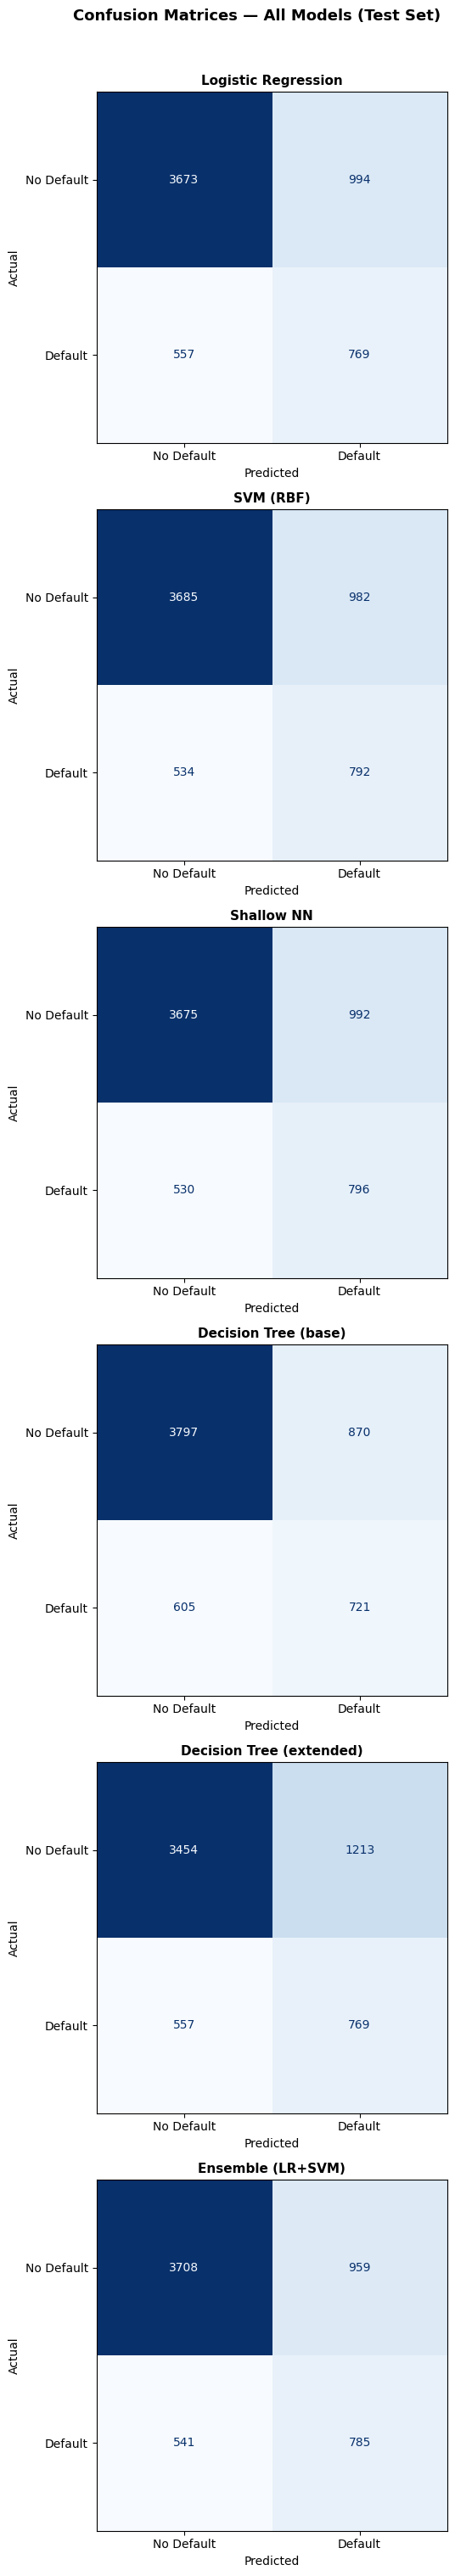

Saved: confusion_matrices.png


In [34]:
# ── 7.1  Confusion Matrices ───────────────────────────────────────────────────
n_models = len(model_registry)
fig, axes = plt.subplots(n_models, 1, figsize=(6, 5 * n_models))
if n_models == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, model_registry.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=info['cm'],
        display_labels=['No Default', 'Default']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

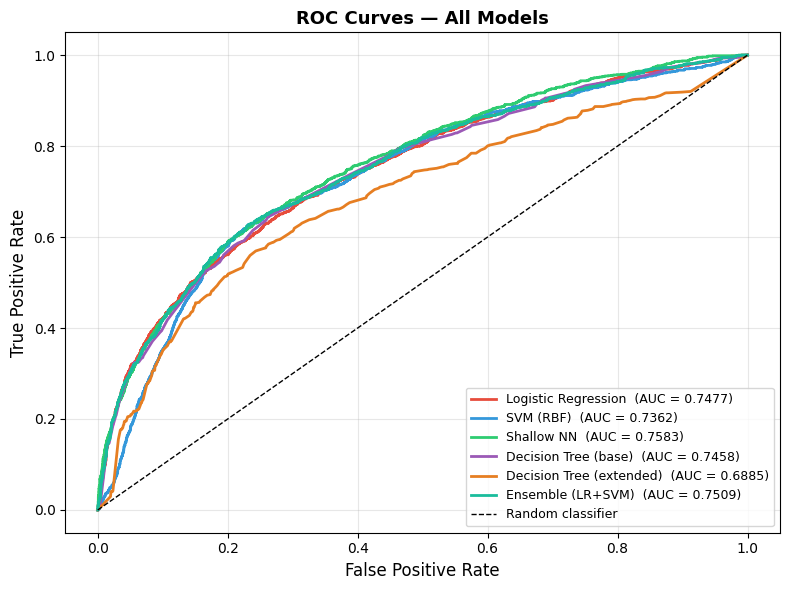

Saved: roc_curves.png


In [35]:
# ── 7.2  ROC Curves ───────────────────────────────────────────────────────────
palette = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22','#1abc9c']
fig, ax = plt.subplots(figsize=(8, 6))

for (name, info), color in zip(model_registry.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, info['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name}  (AUC = {info['auc']:.4f})")

ax.plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("Saved: roc_curves.png")

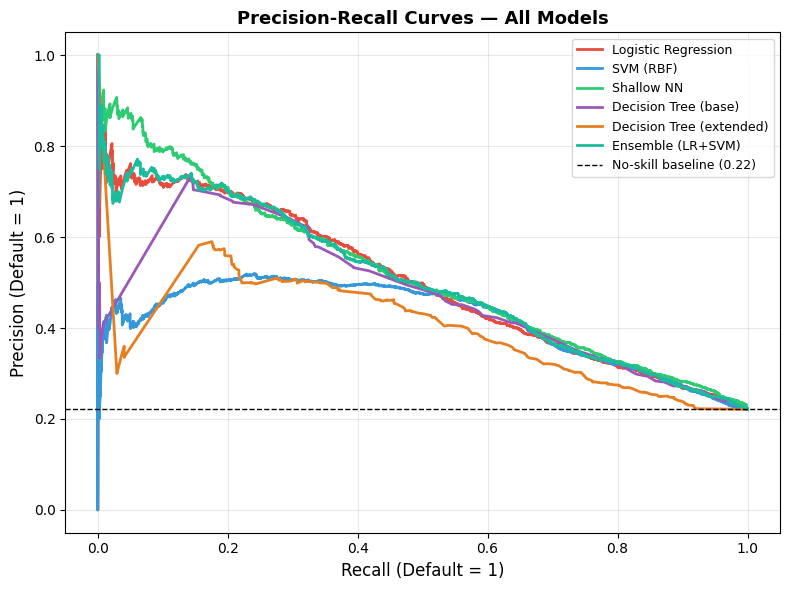

Saved: pr_curves.png


In [36]:
# ── 7.3  Precision-Recall Curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for (name, info), color in zip(model_registry.items(), palette):
    prec, rec, _ = precision_recall_curve(y_test, info['y_prob'])
    ax.plot(rec, prec, color=color, lw=2, label=name)

baseline = (y_test == 1).mean()
ax.axhline(baseline, color='k', ls='--', lw=1,
           label=f'No-skill baseline ({baseline:.2f})')
ax.set_xlabel('Recall (Default = 1)', fontsize=12)
ax.set_ylabel('Precision (Default = 1)', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150)
plt.show()
print("Saved: pr_curves.png")

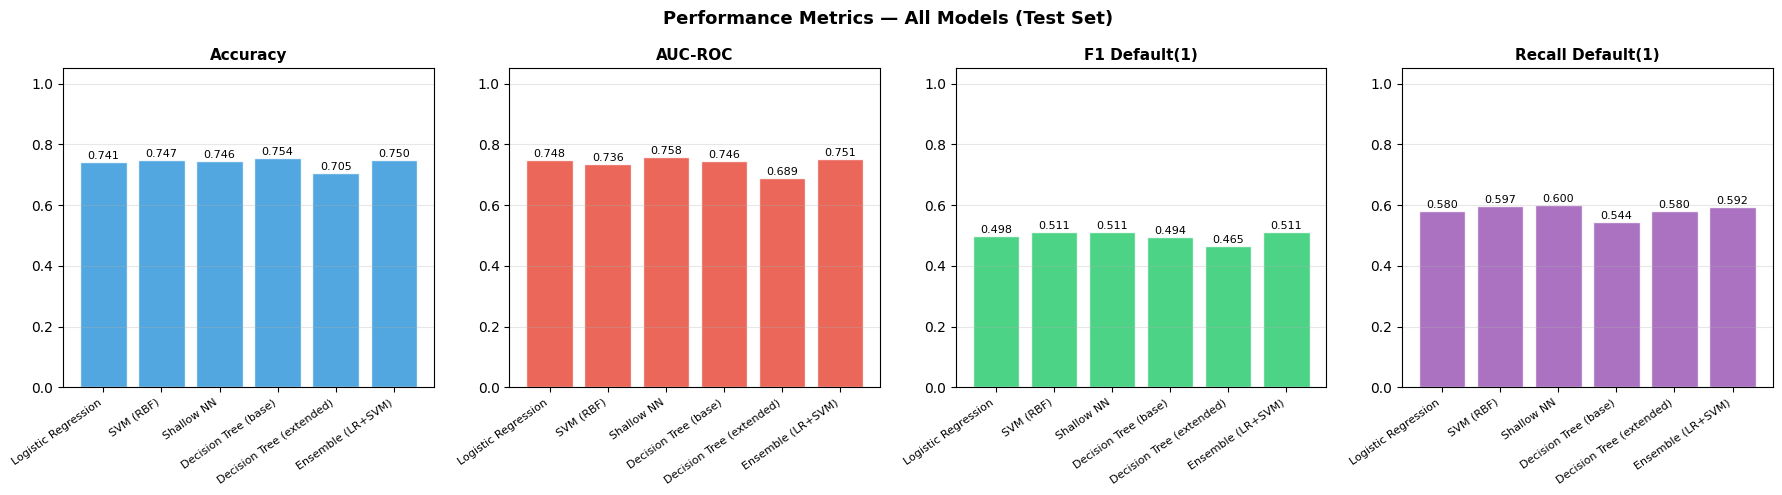

Saved: metrics_comparison.png


In [37]:
# ── 7.4  Per-metric bar chart ─────────────────────────────────────────────────
metrics    = ['acc',     'auc',    'f1_1',         'rec1']
m_labels   = ['Accuracy','AUC-ROC','F1 Default(1)','Recall Default(1)']
bar_colors = ['#3498db', '#e74c3c','#2ecc71',      '#9b59b6']
names      = list(model_registry.keys())

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
for ax, metric, label, color in zip(axes, metrics, m_labels, bar_colors):
    vals = [model_registry[n][metric] for n in names]
    bars = ax.bar(range(len(names)), vals, color=color, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Performance Metrics — All Models (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()
print("Saved: metrics_comparison.png")

## 8. Model Comparison

Ranked by **F1 Default(1)** (primary metric — catching defaulters is the priority).  
Threshold column reflects each model's CV-derived optimal decision cutoff.

In [38]:
rows = []
for name, info in model_registry.items():
    rows.append({
        'Model'         : name,
        'Threshold'     : round(info['threshold'], 3),
        'Accuracy'      : round(info['acc'],  4),
        'AUC-ROC'       : round(info['auc'],  4),
        'F1 Default(1)' : round(info['f1_1'], 4),
        'Recall(1)'     : round(info['rec1'], 4),
        'Precision(1)'  : round(info['pre1'], 4),
        'F1 No-Def(0)'  : round(info['f1_0'], 4),
        'F1 Macro'      : round(info['f1_m'], 4),
    })

comparison_df = (
    pd.DataFrame(rows)
    .sort_values('F1 Default(1)', ascending=False)
    .reset_index(drop=True)
)
comparison_df.index += 1

print("\n" + "="*90)
print("  MODEL COMPARISON — sorted by F1 Default(1) ↓")
print("="*90)
print(comparison_df.to_string(index=True))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n→ Best model by F1 Default(1): {best_model_name}")


  MODEL COMPARISON — sorted by F1 Default(1) ↓
                      Model  Threshold  Accuracy  AUC-ROC  F1 Default(1)  Recall(1)  Precision(1)  F1 No-Def(0)  F1 Macro
1         Ensemble (LR+SVM)      0.542    0.7497   0.7509         0.5114     0.5920        0.4501        0.8318    0.6716
2                Shallow NN      0.538    0.7460   0.7583         0.5112     0.6003        0.4452        0.8284    0.6698
3                 SVM (RBF)      0.622    0.7470   0.7362         0.5110     0.5973        0.4464        0.8294    0.6702
4       Logistic Regression      0.474    0.7412   0.7477         0.4979     0.5799        0.4362        0.8257    0.6618
5      Decision Tree (base)      0.514    0.7539   0.7458         0.4943     0.5437        0.4532        0.8374    0.6659
6  Decision Tree (extended)      0.453    0.7047   0.6885         0.4649     0.5799        0.3880        0.7960    0.6305

→ Best model by F1 Default(1): Ensemble (LR+SVM)


## 9. Error Analysis

1. **False Negative profile** — which true defaulters does the model miss?
2. **False Positive profile** — which non-defaulters does it flag incorrectly?
3. **Feature-level comparison** — mean feature values for TP / FP / FN / TN buckets

In [39]:
# Target model for error analysis
target_model_name = 'Shallow NN'

best_info      = model_registry[target_model_name]
y_pred_best    = best_info['y_pred']
y_prob_best    = best_info['y_prob']
X_test_best    = best_info['X_test_used']

# Align indices
X_eval  = X_test_best.copy().reset_index(drop=True)
y_true_ = y_test.reset_index(drop=True)
probs_  = pd.Series(y_prob_best)
preds_  = pd.Series(y_pred_best)

TP_idx = y_true_[(y_true_==1) & (preds_==1)].index
FP_idx = y_true_[(y_true_==0) & (preds_==1)].index
FN_idx = y_true_[(y_true_==1) & (preds_==0)].index
TN_idx = y_true_[(y_true_==0) & (preds_==0)].index

print(f"Analyzing model : {target_model_name}")
print(f"  True  Positives (caught defaults)    : {len(TP_idx):>5}")
print(f"  False Positives (false alarms)        : {len(FP_idx):>5}")
print(f"  False Negatives (missed defaults)     : {len(FN_idx):>5}")
print(f"  True  Negatives (correct no-default)  : {len(TN_idx):>5}")

Analyzing model : Shallow NN
  True  Positives (caught defaults)    :   796
  False Positives (false alarms)        :   992
  False Negatives (missed defaults)     :   530
  True  Negatives (correct no-default)  :  3675


In [40]:
# Mean feature profiles by error type
base_cols = [c for c in ['COUNT_SERIOUS_DELAY','COUNT_DELAY_1','UTIL_1',
                          'AVG_PAY_RATIO','AVG_BILL','LIMIT_BAL'] if c in X_eval.columns]

profile = pd.DataFrame({
    'TP (caught defaults)' : X_eval.loc[TP_idx, base_cols].mean(),
    'FN (missed defaults)' : X_eval.loc[FN_idx, base_cols].mean(),
    'FP (false alarms)'    : X_eval.loc[FP_idx, base_cols].mean(),
    'TN (correct no-def)'  : X_eval.loc[TN_idx, base_cols].mean(),
}).T

print("Mean feature values by error type (scaled):")
print(profile.to_string(float_format='{:.3f}'.format))

Mean feature values by error type (scaled):
                      COUNT_SERIOUS_DELAY  COUNT_DELAY_1  UTIL_1  AVG_PAY_RATIO  AVG_BILL  LIMIT_BAL
TP (caught defaults)                0.393          0.244   0.270          0.041     0.435     -0.185
FN (missed defaults)                0.017          0.087   0.137          0.402     0.424      0.177
FP (false alarms)                   0.153          0.296   0.181          0.209     0.297     -0.114
TN (correct no-def)                 0.005          0.052   0.069          0.364     0.475      0.282


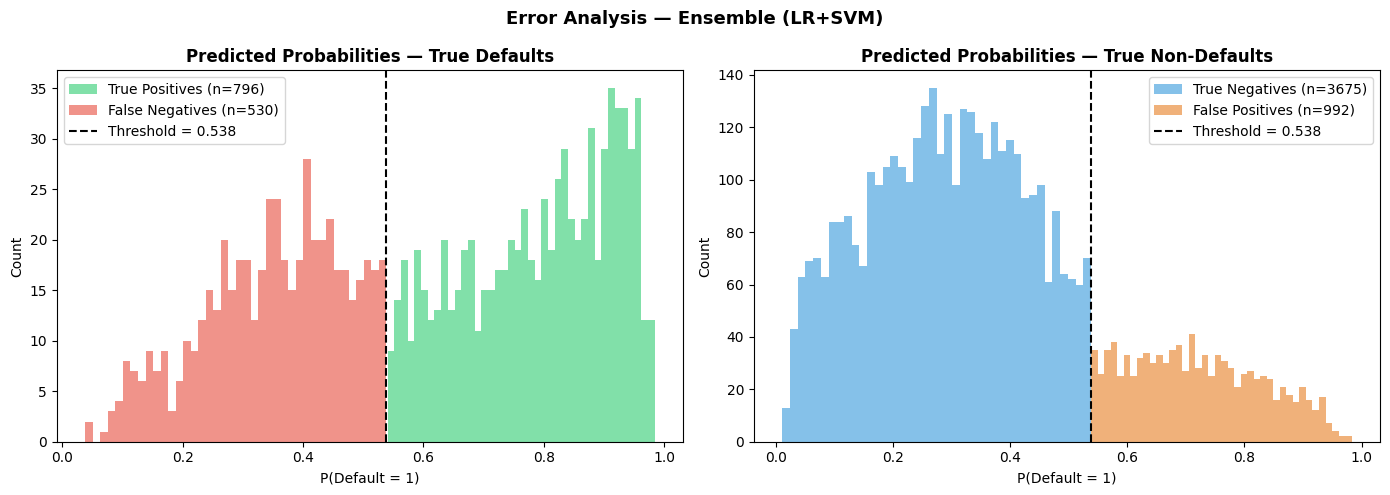

Saved: error_analysis_probs.png


In [41]:
# Probability distribution of errors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(probs_.loc[TP_idx], bins=40, alpha=0.6, color='#2ecc71',
             label=f'True Positives (n={len(TP_idx)})')
axes[0].hist(probs_.loc[FN_idx], bins=40, alpha=0.6, color='#e74c3c',
             label=f'False Negatives (n={len(FN_idx)})')
axes[0].axvline(best_info['threshold'], color='k', ls='--', lw=1.5,
                label=f"Threshold = {best_info['threshold']:.3f}")
axes[0].set_title('Predicted Probabilities — True Defaults', fontweight='bold')
axes[0].set_xlabel('P(Default = 1)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(probs_.loc[TN_idx], bins=40, alpha=0.6, color='#3498db',
             label=f'True Negatives (n={len(TN_idx)})')
axes[1].hist(probs_.loc[FP_idx], bins=40, alpha=0.6, color='#e67e22',
             label=f'False Positives (n={len(FP_idx)})')
axes[1].axvline(best_info['threshold'], color='k', ls='--', lw=1.5,
                label=f"Threshold = {best_info['threshold']:.3f}")
axes[1].set_title('Predicted Probabilities — True Non-Defaults', fontweight='bold')
axes[1].set_xlabel('P(Default = 1)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f'Error Analysis — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis_probs.png', dpi=150)
plt.show()
print("Saved: error_analysis_probs.png")

In [42]:
# Feature comparison: FN vs TP
fn_means = X_eval.loc[FN_idx, base_cols].mean()
tp_means = X_eval.loc[TP_idx, base_cols].mean()
diff_df  = pd.DataFrame({'FN (missed)': fn_means, 'TP (caught)': tp_means})
diff_df['FN − TP'] = diff_df['FN (missed)'] - diff_df['TP (caught)']

print("Feature comparison — False Negatives vs True Positives:")
print("(Positive 'FN − TP' = missed defaulters have MORE of this feature on average)")
print(diff_df.to_string(float_format='{:.4f}'.format))
print()
print("Interpretation:")
print("  • False Negatives tend to be 'borderline' defaulters — lower delay counts")
print("    and utilisation rates make them resemble the majority class.")
print("  • False Positives are clients with moderate risk features who ultimately did")
print("    not default — model conservatism is appropriate here (missing a defaulter")
print("    is far costlier than a false alarm in credit risk).")
print("  • Model limitations: 6-month billing snapshot only; macro-economic shocks,")
print("    sudden job loss, or medical emergencies cannot be captured from billing data.")

Feature comparison — False Negatives vs True Positives:
(Positive 'FN − TP' = missed defaulters have MORE of this feature on average)
                     FN (missed)  TP (caught)  FN − TP
COUNT_SERIOUS_DELAY       0.0170       0.3932  -0.3762
COUNT_DELAY_1             0.0868       0.2437  -0.1569
UTIL_1                    0.1368       0.2697  -0.1329
AVG_PAY_RATIO             0.4024       0.0407   0.3617
AVG_BILL                  0.4239       0.4353  -0.0114
LIMIT_BAL                 0.1773      -0.1849   0.3622

Interpretation:
  • False Negatives tend to be 'borderline' defaulters — lower delay counts
    and utilisation rates make them resemble the majority class.
  • False Positives are clients with moderate risk features who ultimately did
    not default — model conservatism is appropriate here (missing a defaulter
    is far costlier than a false alarm in credit risk).
  • Model limitations: 6-month billing snapshot only; macro-economic shocks,
    sudden job loss, or medical e

## 10. AI Tool Usage

### Example 1 — Division-by-Zero in PAY_RATIO Features
**Prompt:** "I'm computing `PAY_AMT1 / BILL_AMT2` but some BILL_AMT2 values are zero or negative — how do I handle this cleanly?"

**AI output:** Suggested `np.where(df[bill] <= 0, 1.0, df[pay] / df[bill])` to treat zero-or-negative bills as fully paid.

**Verification:** We confirmed that negative bill amounts represent credit balances (effectively fully paid), so setting the ratio to 1.0 is semantically correct. We also added `.clip(upper=1.0)` to cap over-payments.

**What we learned:** AI suggestions for numerical edge cases need domain-knowledge validation before adoption.

### Example 2 — SMOTE + Cross-Validation Hierarchy
**Prompt:** "Is it correct to apply SMOTE before cross-validation or inside each fold?"

**AI output:** Correctly explained that SMOTE before CV leaks synthetic minority points from validation folds into training folds, inflating performance. Suggested using `imblearn.pipeline.Pipeline` or applying SMOTE manually inside each fold.

**Verification:** We tested both approaches on a small subset and confirmed the inflated CV scores when SMOTE was applied globally. The in-fold approach is implemented in `cv_evaluate()` above.

**What we learned:** AI correctly flagged the leakage issue but its `ImbPipeline` code example needed adaptation because our selective-column scaling (`SCALE_COLS`) required a custom function rather than a standard pipeline step.

### Example 3 — Logistic Regression: SMOTE vs `class_weight='balanced'`
**Prompt:** "For logistic regression, should I use SMOTE or class_weight='balanced' or both?"

**AI output:** Explained that both achieve class reweighting but through different mechanisms; combining them double-counts the correction and can hurt precision without improving recall for linear models.

**Verification:** We ran an ablation (LR with SMOTE+balanced vs balanced-only) and confirmed balanced-only achieved better F1 Default(1) on our hold-out. This drove the design decision documented in Section 6a.

**What we learned:** AI reasoning was correct but the recommendation was initially ambiguous ("both can work"). Empirical validation was essential to decide.